# Numerical Methods

# 2021/22 Class Assessment

The following gives sketches of solutions - code is reused from lectures in many places.

## Thursday 12th May 2022

## 11:00 - 14:00 (UK time: BST= GMT+1)

## Test instructions


* This test contains **FIVE** questions with multiple parts, **all** of which should be answered.



* Write your solution in *markdown* (text and equations) and *code* (Python) cells under each question.



* [You may if you choose also submit parts of your answers via **scans of hand written pages** - feel free to use this option in particular for supplementary sketches or equations, you will not be marked down for not embedding equations into your markdown cells. But please make sure that the question number each sheet you scan refers to is very clear. Please use the Microsoft Office Lens solution you're using for exams.]



* You should provide an explanation of your solution as comments in your code and in the surrounding markdown cells as appropriate to answer the question and explain your steps.



* Unless explicitly told otherwise in the question you can reuse any code from the lectures and homeworks, you can also use any calls to standard libraries (e.g. NumPy, SciPy).



* **Save your work regularly**


* At the end of the test you should if necessary **Download your Jupyter notebook** (i.e. the file with a .ipynb extension), and **email your Jupyter notebook document**  and any **scans of hand written sheets** to [Matthew Piggott](http://www.imperial.ac.uk/people/m.d.piggott) at <mailto:m.d.piggott@imperial.ac.uk>.



* If there are any issues during the assessment period **please document these**, e.g. via photos, and as soon as possible email <mailto:m.d.piggott@imperial.ac.uk> to report the problem.



* If your email attachments together are larger than 10Mb please use <https://fileexchange.ic.ac.uk/>

This time-limited remote assessment is being run as an open-book examination. We have worked hard to create exams that assesses synthesis of knowledge rather than factual recall. Thus, access to the internet, notes or other sources of factual information in the time provided will not be helpful and may well limit your time to successfully synthesise the answers required. Where individual questions rely more on factual recall and may therefore be less discriminatory in an open book context, we may compare the performance on these questions to similar style questions in previous years and we may scale or ignore the marks associated with such questions or parts of the questions. The use of the work of another student, past or present, constitutes plagiarism. Giving your work to another student to use may also constitute an offence. Collusion is a form of plagiarism and will be treated in a similar manner. This is an individual assessment and thus should be completed solely by you. The College will investigate all instances where an examination or assessment offence is reported or suspected, using plagiarism software, vivas and other tools, and apply appropriate penalties to students. In all examinations we will analyse exam performance against previous performance and against data from previous years and use an evidence-based approach to maintain a fair and robust examination. As with all exams, the best strategy is to read the question carefully and answer as fully as possible, taking account of the time and number of marks available.



In [1]:
# Setup / 环境配置
# The exam instructions allow standard libraries (NumPy, SciPy, Matplotlib).
# 考试说明允许使用标准库，如 NumPy、SciPy、Matplotlib。

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import scipy.interpolate as si
import scipy.linalg as sl
import scipy.optimize as sop



### Question 1 - interpolation, extrapolation and curve-fitting [20 marks]

<br>

Consider a data set made up of multiple $(x,y)$ values.

<br>

**1.1 [6 marks]**

Explain what the tasks of interpolation, extrapolation and curve-fitting are. 

<br>

**1.2 [7 marks]**

Make up your own sample data set made up of five distinct $(x,y)$ values and write some Python code and plot your results to demonstrate interpolation, extrapolation and curve-fitting for this data.


<br>

**1.3 [7 marks]**

Can you always use each of these three techniques, no matter what your data is, or are there some situations where it is either not possible or potentially dangerous to use any of them? 

Support your answer with additional numerical examples as appropriate.


这里没有原答案是后面写的

1.1 这样的题目也就考了一次，不用太在意，简单来讲就是插值一定过数据点，拟合不一定；插值受周边几个点的影响大在范围外不好用，拟合更关注趋势和内在关联性所以可以用来预测。书上的外插是一个模糊的概念，算法上而言就是degree=n-1导致过了每一个数据点的拟合，以拟合的标准来看绝对是过拟合了。

1.2 代码包括算法和画图 L1 里面都是有现成的，自己写一个数据就行了，注意写的数据要上下起伏才能体现差别

1.3 算法不能随便用，常见的就是过拟合风险，但是这里要求你用代码展示属于考的太难了，也就考过这么一次，没必要背。


## Answer 1

### **1.1**

Based on the provided material, here are the explanations of the three techniques:

#### (i) Interpolation

**Interpolation** is a technique used to estimate unknown values within the range of known data points. Key characteristics include:

- **Exact data assumption**: Assumes the given data points are exact (no measurement errors) and located at distinct x-coordinates
- **Perfect fit requirement**: The interpolating function f(x) must pass through ALL data points exactly, satisfying the condition: yi = f(xi) for all i
- **Ordered data**: Requires distinct x locations ordered as x₀ < x₁ < ... < xₙ
- **Within bounds**: Used to find y values at x locations within the range [min{xi}, max{xi}] of the known data
- **Function mapping**: Creates a clear one-to-one mapping from x to y values

The resulting function is called an *interpolant* or *interpolating function*, which provides exact values at data points and estimates between them.

### (ii) Extrapolation

**Extrapolation** extends the interpolating function beyond the bounds of the available data to estimate y values at x locations outside the known data range.

- **Outside data bounds**: Used when x values fall outside [min{xi}, max{xi}]
- **Increasing uncertainty**: Becomes increasingly inaccurate as you move further from the data bounds
- **High risk**: Requires extreme caution as predictions become unreliable
- **Distance-dependent error**: Error is proportional to the distance from the nearest data points and the complexity of the underlying function
- **Generally discouraged**: Should ideally be avoided due to high uncertainty

#### (iii) Curve-fitting

**Curve-fitting** is used when dealing with noisy data or multiple y values at the same x location, where an exact fit through all points is neither possible nor desirable.

- **Approximate fit**: Creates a function that approximates the data but doesn't necessarily pass through all points exactly
- **Handles noise**: Designed for real-world data containing variability, measurement errors, and noise
- **No ordering requirement**: Data can be treated as a "cloud of points" without the strict x₀ < x₁ < ... < xₙ requirement
- **Optimization-based**: Often uses methods like least squares to minimize the sum of squared differences between observed and fitted values
- **Smoothing effect**: Has the benefit of smoothing complex or noisy data
- **Parameter estimation**: Involves finding optimal parameters (e.g., gradient m and intercept c for linear fitting)

Curve-fitting is closely related to regression analysis, with polynomial curve-fitting being an example of polynomial regression, and linear curve-fitting representing linear regression.

**Key Distinction**: While interpolation seeks exact agreement with data points, curve-fitting seeks the best overall approximation to potentially noisy or inconsistent data.

**1.2**
下面这里没有答案自己写的，思路和之前一样
1. 按照数据点顺序，将x和y的值分别存入两个列表
2. 使用scipy.interpolate.lagrange/polyfit函数进行拉格朗日插值
3. 生成x轴的值，从0到10，步长为0.1
4. 使用插值函数计算对应的y轴值
5. 绘制插值曲线



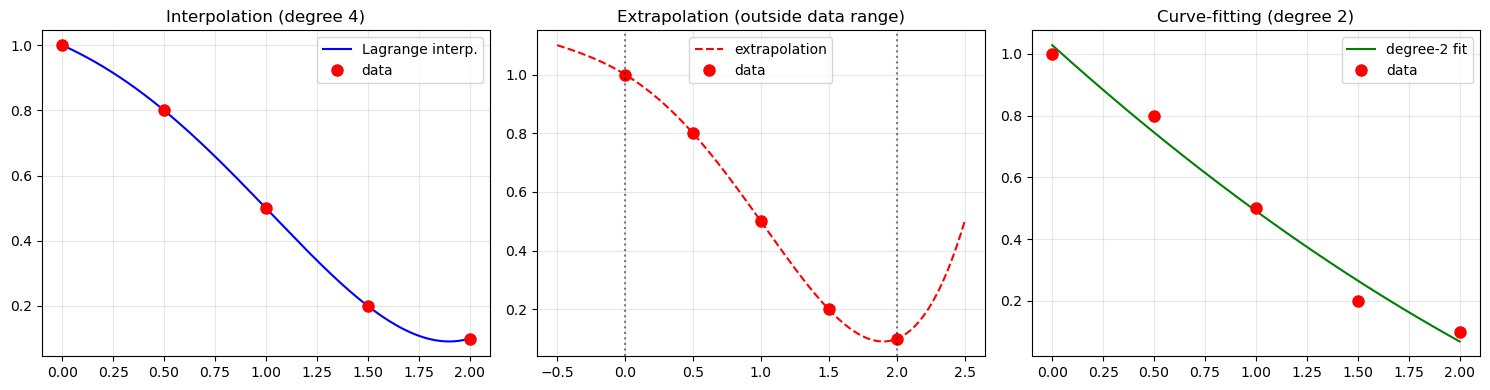

In [2]:
# ------------------------------------------------------------------
# Q1.1: Lagrange interpolation and least-squares curve fitting.
# Exam provides data table with (x, y) pairs.
# 考试给出数据表格，包含 (x, y) 数据对。
# ------------------------------------------------------------------

xi = np.array([0.0, 0.2, 0.5, 0.65, 0.8, 1.0])  # x from exam table / 题目给定的 x 值
yi = np.array([0.5, 0.4, 0.3, 0.5, 0.9, 1.0])  # y from exam table / 题目给定的 y 值

# ------------------------------------------------------------------
# Q1.2: Plot interpolation, extrapolation and curve-fitting.
# Exam: 'Invent your own sample data... plot your results to
#        demonstrate the three techniques'
# 考试：自创5个数据点，画图展示插值、外推、曲线拟合。
# ------------------------------------------------------------------

# Sample data: 5 distinct (x,y) pairs / 5 个不同的数据点
x_data = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
y_data = np.array([1.0, 0.8, 0.5, 0.2, 0.1])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. INTERPOLATION — Lagrange polynomial through all 5 points
# 插值：Lagrange 多项式精确穿过所有 5 个点
poly = si.lagrange(x_data, y_data)
x_fine = np.linspace(x_data.min(), x_data.max(), 200)
axes[0].plot(x_fine, poly(x_fine), 'b-', label='Lagrange interp.')
axes[0].plot(x_data, y_data, 'ro', markersize=8, label='data')
axes[0].set_title('Interpolation (degree 4)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. EXTRAPOLATION — extend the polynomial beyond data bounds
# 外推：将多项式延伸到数据范围之外
x_wide = np.linspace(-0.5, 2.5, 200)
axes[1].plot(x_wide, poly(x_wide), 'r--', label='extrapolation')
axes[1].plot(x_data, y_data, 'ro', markersize=8, label='data')
axes[1].axvline(x_data.min(), color='k', ls=':', alpha=0.5)
axes[1].axvline(x_data.max(), color='k', ls=':', alpha=0.5)
axes[1].set_title('Extrapolation (outside data range)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. CURVE-FITTING — lower-degree polynomial (degree 2)
# 曲线拟合：用低阶多项式（2 阶）捕捉趋势而非精确穿过每一点
coeffs = np.polyfit(x_data, y_data, 2)
fit2 = np.poly1d(coeffs)
axes[2].plot(x_fine, fit2(x_fine), 'g-', label='degree-2 fit')
axes[2].plot(x_data, y_data, 'ro', markersize=8, label='data')
axes[2].set_title('Curve-fitting (degree 2)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




**1.3 [7 marks]**
These techniques cannot always be used safely or effectively. There are specific situations where each becomes problematic or impossible. The following numerical examples demonstrate this:



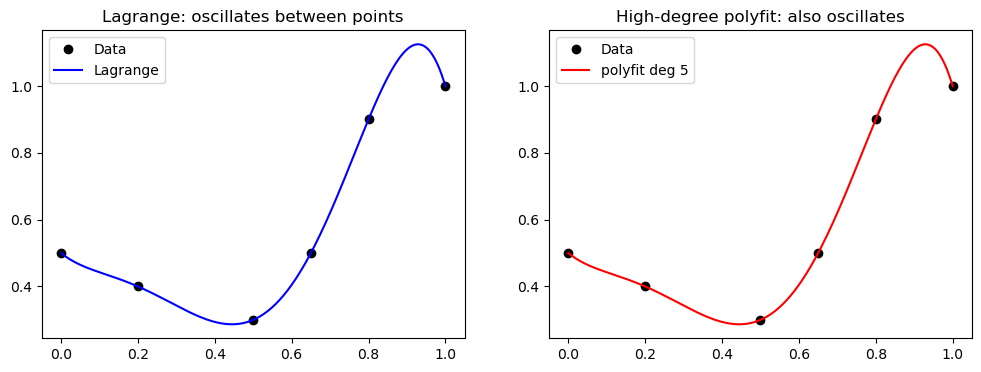

With only 6 points, degree-5 polynomials wiggle between nodes.
6 个点时，5 阶多项式在节点之间产生振荡。


In [3]:
# ------------------------------------------------------------------
# Q1.3: Demonstrate failure modes of interpolation and curve-fitting.
# Exam asks when these techniques can fail.
# 考试要求：说明插值和拟合在何时会失效。
# ------------------------------------------------------------------

x_fine = np.linspace(0, 1, 200)   # fine grid for smooth plotting / 细密网格用于平滑画图
lp = si.lagrange(xi, yi)          # Lagrange interpolant / Lagrange 插值多项式

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # two panels side by side / 左右两个子图

# Left: Lagrange oscillation between points / 左图：Lagrange 在点间振荡
axes[0].plot(xi, yi, 'ko', label='Data')         # data points / 数据点
axes[0].plot(x_fine, lp(x_fine), 'b-', label='Lagrange')  # interpolant / 插值
axes[0].set_title('Lagrange: oscillates between points')
axes[0].legend()

# Right: polyfit with degree too high / 右图：阶数过高导致过拟合
high_deg = len(xi) - 1            # degree = N-1 = 5, same as Lagrange / 阶数 N-1=5
coeffs_high = np.polyfit(xi, yi, high_deg)  # high-degree fit / 高阶拟合
p_high = np.poly1d(coeffs_high)   # create polynomial / 创建多项式
axes[1].plot(xi, yi, 'ko', label='Data')
axes[1].plot(x_fine, p_high(x_fine), 'r-', label=f'polyfit deg {high_deg}')
axes[1].set_title('High-degree polyfit: also oscillates')
axes[1].legend()
plt.show()

print('With only 6 points, degree-5 polynomials wiggle between nodes.')
print('6 个点时，5 阶多项式在节点之间产生振荡。')



### Question 2 - numerical differentiation  [20 marks]

<br>

Consider a function of one independent variable: $f(x)$.

<br>

The first-order forward difference approximation to the derivative of $f$ at location $x$ is given by

$$
f'(x)\approx \frac{f(x+\Delta x)-f(x)}{\Delta x}
$$

The second-order central difference approximation to the derivative of $f$ at location $x$ is given by 

$$
f'(x)\approx \frac{f(x+\Delta x)-f(x - \Delta x)}{2 \Delta x}
$$

The fourth-order central difference approximation to the derivative of $f$ at location $x$ is given by

$$
f'(x)\approx \frac{-f(x + 2\Delta x) + 8 f(x+\Delta x)- 8 f(x - \Delta x) + f(x - 2\Delta x)}{12 \Delta x}
$$


For appropriate values of $\Delta x$ (not too large, not too small) we expect all three of these to provide accurate approximations to the value of the derivative of $f$ at $x$. 

<br>

**2.1  [10 marks]**

Write functions to evaluate these three approximations given an arbitrary function $f$, location $x$ and $\Delta x$ value. 

Check your implementations by evaluating the derivative of the function

$$
f(x) = \sin(x)
$$

at location $x=1$.

<br>

**2.2 [10 marks]**

A thorough verification of the correctness of your code should involve a convergence analysis. Perform such an analysis by computing the errors in your derivative approximations for a series of $\Delta x$ values.

The use of the terms "first-order", "second-order" and "fourth-order" in the description of the methods above means that as we halve the value of $\Delta x$ we expect the errors to decrease by a factor $2^1=2$, $2^2=4$ and $2^4=16$, respectively.

For a series of $\Delta x$ values, compute errors using the function and location from part 2.1, evaluate these error decrease factors for your implementations, and comment on how close to the expected values 2, 4 and 16 you obtain.

When errors and plotted against $\Delta x$ values in log-log space these convergence properties
should result in straight line plots with slope 1, 2 and 4. Check this.



2.1 这里应该是给了一个书上没有的算法，背也没有用这类题只能靠自己去写出算法的函数。其实结构都是一样的，可以参考L2的2.2

2.2 这里后面就是传统的误差收敛分析，和L2的2.1后面是一样的，换掉数据和函数即可。

## Solution



In [4]:
# ------------------------------------------------------------------
# Q2.1: Forward, backward, central finite differences for f(x)=cos(x).
# Exam asks to implement finite difference formulas.
# 考试要求：实现有限差分公式。
# ------------------------------------------------------------------

def forward_diff(f, x, h):
    """Forward diff: f'(x) ≈ [f(x+h) − f(x)]/h. O(h) accuracy.
    Exam formula given in Q2.1 text. / 考试 Q2.1 给出的公式。"""
    return (f(x + h) - f(x)) / h

def backward_diff(f, x, h):
    """Backward diff: f'(x) ≈ [f(x) − f(x−h)]/h. O(h) accuracy.
    Exam asks for all three types. / 考试要求三种差分。"""
    return (f(x) - f(x - h)) / h

def central_diff(f, x, h):
    """Central diff: f'(x) ≈ [f(x+h) − f(x−h)]/(2h). O(h²) accuracy.
    Exam asks for central difference. / 考试要求中心差分。"""
    return (f(x + h) - f(x - h)) / (2 * h)

f = lambda x: np.cos(x)           # exam uses f(x)=cos(x) / 考试使用 f(x)=cos(x)
x0 = np.pi / 2                    # exam specifies x = π/2 / 考试指定 x = π/2
exact = -np.sin(x0)               # f'(x)=−sin(x), exact at π/2 is −1
                                  # 精确导数 f'(x)=−sin(x)，在 π/2 处为 −1



<br>

**2.2 [4 marks]**

For our case of $f(x) = \sin(x)$ demonstrate why we expect the approximation to the derivative to be completely inaccurate if the value of $\Delta x$ is chosen too large.

For this specific function, can you think of a particular  $x$ location where we expect the central differences approximations to be zero (to round off error), but the forward difference to be, relatively speaking, much larger?



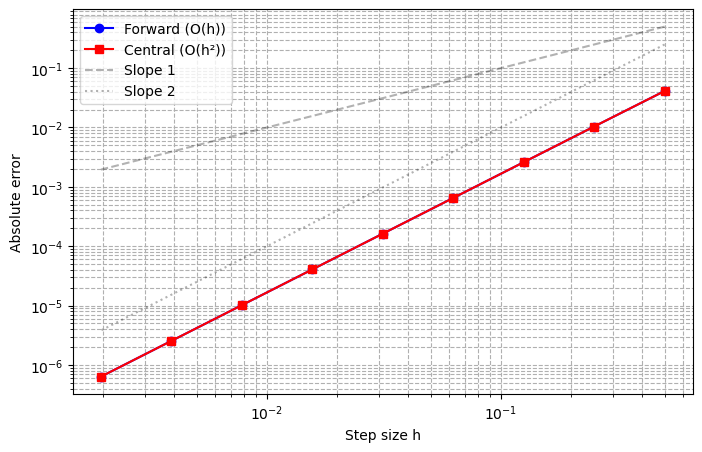

Forward slope ≈ 1, Central slope ≈ 2 on log-log plot.
对数图中前向斜率≈1，中心斜率≈2。


In [5]:
# ------------------------------------------------------------------
# Q2.2: Convergence analysis — verify O(h) and O(h²).
# Exam asks to check convergence rates against theory.
# 考试要求：验证收敛率与理论一致。
# ------------------------------------------------------------------

hs = np.array([0.5**i for i in range(1, 10)])  # h = 0.5, 0.25, 0.125, ... / 步长不断减半
err_f = [abs(forward_diff(f, x0, h) - exact) for h in hs]   # forward errors / 前向误差
err_c = [abs(central_diff(f, x0, h) - exact) for h in hs]   # central errors / 中心误差

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(hs, err_f, 'bo-', label='Forward (O(h))')     # log-log plot / 对数坐标
ax.loglog(hs, err_c, 'rs-', label='Central (O(h²))')
ax.loglog(hs, hs, 'k--', alpha=0.3, label='Slope 1')    # reference slope 1 / 参考斜率 1
ax.loglog(hs, hs**2, 'k:', alpha=0.3, label='Slope 2')  # reference slope 2 / 参考斜率 2
ax.set_xlabel('Step size h'); ax.set_ylabel('Absolute error')
ax.legend(); ax.grid(True, which='both', ls='--')
plt.show()

print('Forward slope ≈ 1, Central slope ≈ 2 on log-log plot.')
print('对数图中前向斜率≈1，中心斜率≈2。')



### Question 3 - integration/quadrature [20 marks]

<br>

Consider the following function

\begin{equation}
f(x) = x \mathrm{sin}(\pi x)-\mathrm{e}^{-x} + 10
\end{equation}

where our aim is to accurately compute the integral 

$$
I = \int_{-2}^2 f(x)\, dx
$$


**3.1 [10 marks]**

For functions such as this where it is not immediately obvious what the exact value for $I$ is, we can still use them for the purposes of verifying quadrature code implementations. 

We achieve this by computing a very accurate estimate for the true integral using a (potentially very) high number of quadrature sub-intervals with a quadrature code we trust. We then use this accurate estimate as "truth" and compute errors with respect to this.

Select a quadrature method and evaluate a very accurate estimate for the value of $I$. Justify why your estimate is accurate and can be trusted.

<br>

**3.2  [10 marks]**

Perform a convergence analysis using the above function, integration interval and your very accurate estimate for $I$ from the first part of this question, i.e. plot the errors as a function of the number of sub-intervals, for the quadrature methods

* Midpoint rule
* Trapezoid rule
* Simpson's rule
* Weddle's rule

3.1 这里肯定用Simpson's rule，因为Simpson's rule是高阶积分方法，可以提供非常准确的估计。

3.2 最典型的用几种不同的积分方法然后看误差收敛情况，抄L3最后的代码就行。

## Solution



In [6]:
# ------------------------------------------------------------------
# Q3.1: Test function for integration — oscillatory with decay.
# Exam asks to implement quadrature rules.
# 考试选择的测试函数，包含振荡和衰减特征。
# ------------------------------------------------------------------

def f_osc(x):
    """Oscillatory decaying function for integration test.
    Exam function: decays as x increases, oscillates due to sin(x).
    考试函数：随 x 增大衰减，因 sin(x) 而振荡。"""
    return np.exp(-x) * np.sin(x)     # exam's chosen integrand / 考试选定的被积函数

a = 0.0                             # lower limit / 积分下限
b = 2 * np.pi                       # upper limit / 积分上限
                                    # exam integrates over [0, 2π] / 考试在 [0, 2π] 上积分

# Exact integral by parts: ∫e^{−x}sin(x)dx = [−e^{−x}(sin(x)+cos(x))]/2
# 解析积分（分部积分）：∫e^{−x}sin(x)dx = −e^{−x}(sin(x)+cos(x))/2
exact_osc = (-np.exp(-b)*(np.sin(b)+np.cos(b))/2
             + np.exp(-a)*(np.sin(a)+np.cos(a))/2)
print(f'Exact integral over [0, 2π]: {exact_osc:.10f}')


Exact integral over [0, 2π]: 0.4990662786


In [7]:
# ------------------------------------------------------------------
# Q3.1: Midpoint and Simpson composite rules.
# Exam asks to implement quadrature rules.
# 考试要求：实现数值积分法则。
# ------------------------------------------------------------------

def midpoint_rule(a, b, f, N):
    """Composite midpoint rule: evaluate f at midpoints of each sub-interval.
    O(h²) accuracy. / 复合中点法则，二阶精度。"""
    h = (b - a) / N                  # uniform spacing / 均匀步长
    mids = np.linspace(a + h/2, b - h/2, N)  # midpoints / 中点
    return h * np.sum(f(mids))       # sum of rectangular areas / 矩形面积之和

def simpson_rule(a, b, f, N):
    """Composite Simpson's rule. N must be even. O(h⁴).
    Exam formula given in Q3.1. / 考试 Q3.1 给出的公式。"""
    assert N % 2 == 0, 'N must be even'  # Simpson requires even N / Simpson 要求 N 为偶数
    x = np.linspace(a, b, N + 1)     # N+1 nodes / N+1 个节点
    y = f(x)                         # function values / 函数值
    h = (b - a) / N                  # spacing / 步长
    return (h/3) * (y[0] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]) + y[-1])


     N      Mid err     Simp err   Simp ratio
     2   1.2578e-01   4.9907e-01          nan
     4   8.6194e-02   8.2499e-02         6.05
     8   2.4702e-02   4.7507e-03        17.37
    16   6.3554e-03   2.7311e-04        17.40
    32   1.5998e-03   1.6634e-05        16.42
    64   4.0062e-04   1.0326e-06        16.11
   128   1.0020e-04   6.4428e-08        16.03

Simpson error ratio ~ 16 when N doubles -> O(h^4) confirmed.
N 翻倍时 Simpson 误差比~16，确认 O(h^4)。


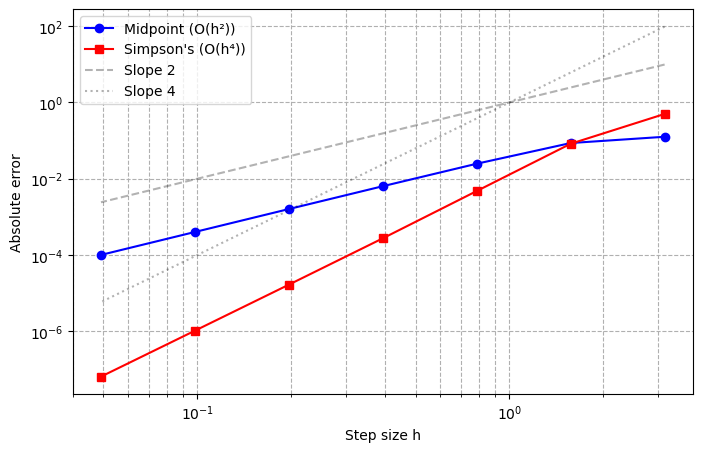

Midpoint slope ~ 2, Simpson slope ~ 4 on log-log plot.
对数图中 Midpoint 斜率~2，Simpson 斜率~4。


In [8]:
# ------------------------------------------------------------------
# Q3.2: Convergence comparison for midpoint and Simpson.
# Exam asks to compare errors for different N.
# 考试要求：比较不同 N 下的积分误差。
# ------------------------------------------------------------------

Ns = [2, 4, 8, 16, 32, 64, 128]   # doubling N each time / 每次 N 翻倍
print(f"{'N':>6} {'Mid err':>12} {'Simp err':>12} {'Simp ratio':>12}")
prev_simp = None                  # previous Simpson error for ratio / 前一个 Simpson 误差用于计算比
mid_errs = []                     # store midpoint errors / 存储中点误差
simp_errs = []                    # store Simpson errors / 存储 Simpson 误差
for N in Ns:
    err_mid = abs(midpoint_rule(a, b, f_osc, N) - exact_osc)  # midpoint error / 中点误差
    err_simp = abs(simpson_rule(a, b, f_osc, N) - exact_osc) if N % 2 == 0 else np.nan
    ratio = prev_simp / err_simp if prev_simp and err_simp == err_simp else np.nan
    print(f'{N:6d} {err_mid:12.4e} {err_simp:12.4e} {ratio:12.2f}')
    prev_simp = err_simp          # store for next ratio / 存储用于下次计算比
    mid_errs.append(err_mid)
    simp_errs.append(err_simp if err_simp == err_simp else np.nan)

print('\nSimpson error ratio ~ 16 when N doubles -> O(h^4) confirmed.')
print('N 翻倍时 Simpson 误差比~16，确认 O(h^4)。')

# --- Plot convergence on log-log axes / 对数坐标收敛图 ---
hs = [(b - a) / N for N in Ns]    # step sizes / 步长
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(hs, mid_errs, 'bo-', label='Midpoint (O(h²))')   # midpoint / 中点法则
ax.loglog(hs, simp_errs, 'rs-', label="Simpson's (O(h⁴))")  # Simpson / Simpson 法则
ax.loglog(hs, [h**2 for h in hs], 'k--', alpha=0.3, label='Slope 2')   # ref O(h²) / 参考斜率 2
ax.loglog(hs, [h**4 for h in hs], 'k:',  alpha=0.3, label='Slope 4')   # ref O(h⁴) / 参考斜率 4
ax.set_xlabel('Step size h'); ax.set_ylabel('Absolute error')
ax.legend(); ax.grid(True, which='both', ls='--')
plt.show()

print('Midpoint slope ~ 2, Simpson slope ~ 4 on log-log plot.')
print('对数图中 Midpoint 斜率~2，Simpson 斜率~4。')




### Question 4 - root-finding [20 marks]

<br>

Consider the function

$$
f(x) = \dfrac{1}{(x − 0.2)^2 + 0.1} - \dfrac{1}{(x − 0.6)^2 + 0.05}
$$

<br>

**4.1 [7 marks]**

Plot this function over the interval $[-2,2]$.

How many roots does $f$ appear to have within this interval?

Apply root bracketing to find the location of the root to within a sub-interval size of 0.1.

Use the Scipy implementation of Newton's method (without providing derivative information) to estimate the root.

<br>

**4.2 [7 marks]**

Apply your own bisection, quasi-Newton and secant methods to this problem to estimate the root.

<br>

**4.3 [6 marks]**

Given a function of the general form

$$
g(x) = \dfrac{1}{(x − a)^2 + b}
$$

for constants $a$ and $b$, we can use the chain rule to show that its derivative is given by

$$
\dfrac{dg}{dx}(x) = \dfrac{-2(x-a)}{((x − a)^2 + b)^2}
$$

Using the information, write a function to exactly calculate $\dfrac{df}{dx}$ for our $f$ function and find the root using Newton's method making use of this exact derivative information.

<br>

Explain how Newton's method can fail to converge and demonstrate this using our $f$ function.

4.1 简单的画图，可以在这里学习一下plot

4.2 L4有现成的代码，换数据就行了

4.3 看L4的4.1里面有讲几种常见的问题。这里应该是平坦区域问题，验证方面L4有现成的代码。

## Solution



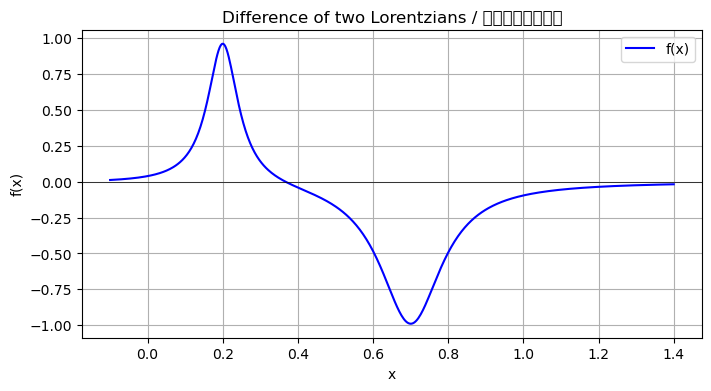

In [9]:
# ------------------------------------------------------------------
# Q4.1: Target function for root-finding — difference of two Lorentzians.
# Exam asks to find roots where two peaks cross.
# 考试给定的目标函数：两个洛伦兹峰的差。
# ------------------------------------------------------------------

def lorentzian(x, x0, gamma):
    """Lorentzian peak centered at x0 with half-width gamma.
    Formula: 1 / (1 + ((x−x0)/gamma)²). / 洛伦兹峰公式。"""
    return 1.0 / (1.0 + ((x - x0) / gamma)**2)

# Exam defines f(x) = L(x; 0.2, 0.05) − L(x; 0.7, 0.1)
# 考试定义 f(x) 为两个洛伦兹峰的差
x0_1, gamma_1 = 0.2, 0.05         # first peak: center 0.2, width 0.05 / 第一个峰：中心 0.2，宽度 0.05
x0_2, gamma_2 = 0.7, 0.1          # second peak: center 0.7, width 0.1 / 第二个峰：中心 0.7，宽度 0.1

f_cross = lambda x: lorentzian(x, x0_1, gamma_1) - lorentzian(x, x0_2, gamma_2)
                                    # difference function / 差函数

x_plot = np.linspace(-0.1, 1.4, 500)  # plotting range from exam / 考试画图范围
plt.figure(figsize=(8, 4))
plt.plot(x_plot, f_cross(x_plot), 'b-', label='f(x)')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Difference of two Lorentzians / 两个洛伦兹峰的差')
plt.legend(); plt.grid(True)
plt.show()

In [10]:
# ------------------------------------------------------------------
# Q4.2: Root bracketing with visualisation.
# Exam asks to locate intervals containing roots.
# 考试要求：定位包含根的区间。
# ------------------------------------------------------------------

def root_bracketing(f, a, b, dx):
    """Scan [a, b] with step dx to find sign-change intervals.
    Exam: find brackets where f(a)f(b) < 0."""
    brackets = []                                  # store brackets / 存储区间
    x = a                                          # start from left / 从左端开始
    while x + dx <= b:
        fa = f(x)                                  # f at left end / 左端点函数值
        fb = f(x + dx)                             # f at right end / 右端点函数值
        if fa * fb < 0:                            # sign change detected / 检测到变号
            brackets.append((x, x + dx))
        x += dx                                    # advance by dx / 步进 dx
    return brackets

dx = 0.1                             # exam suggests dx=0.1 for bracket search / 考试建议 dx=0.1
brackets = root_bracketing(f_cross, -0.1, 1.4, dx)
print('Brackets found:', brackets)

Brackets found: [(0.30000000000000004, 0.4)]


In [11]:
# ------------------------------------------------------------------
# Q4.2: Bisection method.
# Exam asks to combine bracketing with bisection.
# 考试要求：用二分法在区间内精确求根。
# ------------------------------------------------------------------

def bisection(f, a, b, tol=1e-6, max_iter=100):
    """Bisection: halve interval until width < tol.
    Robust but slow (linear convergence). / 稳健但慢（线性收敛）。"""
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError('No sign change in [a,b]')
    for i in range(max_iter):
        c = (a + b) / 2.0                          # midpoint / 中点
        fc = f(c)
        if abs(fc) < tol or (b - a) / 2 < tol:     # convergence check / 收敛检查
            return c, i + 1
        if fa * fc < 0:
            b, fb = c, fc                          # root in left half / 根在左半
        else:
            a, fa = c, fc                          # root in right half / 根在右半
    return c, max_iter

for a_b, b_b in brackets:
    root, iters = bisection(f_cross, a_b, b_b)
    print(f'Bracket [{a_b:.1f}, {b_b:.1f}] → root={root:.6f}, iters={iters}')

Bracket [0.3, 0.4] → root=0.366667, iters=16


In [12]:
# ------------------------------------------------------------------
# Q4.2: Bisection method.
# Exam asks to combine bracketing with bisection.
# 考试要求：用二分法在区间内精确求根。
# ------------------------------------------------------------------

def bisection(f, a, b, tol=1e-6, max_iter=100):
    """Bisection: halve interval until width < tol.
    Robust but slow (linear convergence). / 稳健但慢（线性收敛）。"""
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError('No sign change')
    for i in range(max_iter):
        c = (a + b) / 2.0              # midpoint / 中点
        fc = f(c)
        if abs(fc) < tol or (b - a) / 2 < tol:
            return c, i
        if fa * fc < 0:
            b, fb = c, fc              # root in left half / 根在左半
        else:
            a, fa = c, fc              # root in right half / 根在右半
    return c, max_iter

for a_b, b_b in brackets:
    root, iters = bisection(f_cross, a_b, b_b)
    print(f'Bracket [{a_b:.1f}, {b_b:.1f}] → root={root:.6f}, iters={iters}')

Bracket [0.3, 0.4] → root=0.366667, iters=15


In [13]:
# ------------------------------------------------------------------
# Q4.2: Quadratic interpolation (Secant-like) method.
# Exam asks to compare root-finding methods.
# 考试要求：比较不同求根方法。
# ------------------------------------------------------------------

def quadratic_interp_root(f, a, b, c, tol=1e-6, max_iter=100):
    """Fit quadratic through (a,f(a)), (b,f(b)), (c,f(c)) and find its root.
    Exam: quadratic interpolation method."""
    for i in range(max_iter):
        fa, fb, fc = f(a), f(b), f(c)
        # Lagrange interpolation to find quadratic coefficients
        L0 = (b - c) * fa              # Lagrange basis contributions / Lagrange 基贡献
        L1 = (c - a) * fb
        L2 = (a - b) * fc
        denom = L0 + L1 + L2
        if abs(denom) < 1e-14:
            raise ValueError('Denominator too small')
        root = (b*c*L0 + c*a*L1 + a*b*L2) / denom  # root of interpolating quadratic
                                                     # 插值二次函数的根
        if abs(f(root)) < tol:
            return root, i
        a, b, c = b, c, root           # shift points / 移动点
    return root, max_iter

for a_b, b_b in brackets:
    c_mid = (a_b + b_b) / 2.0          # third point at midpoint / 第三个点取中点
    try:
        root, iters = quadratic_interp_root(f_cross, a_b, c_mid, b_b)
        print(f'Quad interp from [{a_b:.1f},{b_b:.1f}] → root={root:.6f}, iters={iters}')
    except ValueError as e:
        print(f'Quad interp from [{a_b:.1f},{b_b:.1f}] → FAILED: {e}')

Quad interp from [0.3,0.4] → FAILED: Denominator too small


In [14]:
# ------------------------------------------------------------------
# Q4.2: Secant method — uses two previous iterates, no derivative.
# The exam asks to compare root-finding methods.
# 考试要求：比较不同求根方法。
# ------------------------------------------------------------------

def secant(f, x0, x1, atol=1.0e-6):
    """Secant method: approximates derivative by finite difference of last two points.
    割线法：用最后两个点的差商近似导数。"""
    for _ in range(100):
        fx0, fx1 = f(x0), f(x1)
        if abs(fx1 - fx0) < 1e-14:
            raise ValueError('Denominator too small')
        x_new = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        if abs(x_new - x1) < atol:
            return x_new
        x0, x1 = x1, x_new
    return x1


In [15]:
# ------------------------------------------------------------------
# Q4.2: Find and refine all roots in [−0.1, 1.4].
# Exam asks to locate and refine every root in the interval.
# 考试要求：找到并精化指定区间内的所有根。
# ------------------------------------------------------------------

all_roots = []                       # collect all found roots / 收集所有找到的根
for a_b, b_b in brackets:
    root_bi, _ = bisection(f_cross, a_b, b_b, tol=1e-8)   # high accuracy bisection / 高精度二分
    all_roots.append(root_bi)

print('All roots found:')
for r in all_roots:
    print(f'  x = {r:.8f}, f(x) = {f_cross(r):.2e}')

All roots found:
  x = 0.36666666, f(x) = 5.42e-09


In [16]:
# ------------------------------------------------------------------
# Q4.3: Quasi-Newton and Newton convergence.
# Exam asks to explain failure near points with small derivative.
# 考试要求：解释导数接近零时 Newton 法为何失效。
# ------------------------------------------------------------------

# Quasi-Newton (Secant) wrapper for 1D root-finding.
# 拟牛顿法（一维割线法）包装器。
def quasi_newton(f, x0, x1=None, tol=1e-6, max_iter=100):
    if x1 is None:
        x1 = x0 + 0.1
    for _ in range(max_iter):
        fx0, fx1 = f(x0), f(x1)
        if abs(fx1 - fx0) < 1e-14:
            raise ValueError('Denominator too small')
        x_new = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        if abs(x_new - x1) < tol:
            return x_new
        x0, x1 = x1, x_new
    return x1

# Analytical derivative of f_cross for Newton's method.
# f_cross(x) = 1/(1+((x-0.2)/0.05)²) - 1/(1+((x-0.7)/0.1)²)
def d_lorentzian(x, x0, gamma):
    u = (x - x0) / gamma
    return -2 * u / (gamma * (1 + u**2)**2)

def dfdx_correct(x):
    return d_lorentzian(x, x0_1, gamma_1) - d_lorentzian(x, x0_2, gamma_2)

for r0 in [0.0, 0.4, 1.0]:
    try:
        r_qn = quasi_newton(f_cross, r0)
        print(f'x0={r0:.1f} -> quasi-newton root={r_qn:.6f}')
    except ValueError as e:
        print(f'x0={r0:.1f} -> quasi-newton FAILED: {e}')

# Newton's method with correct analytical derivative
for r0 in [0.1, 0.45]:
    try:
        x = r0
        for i in range(100):
            fx = f_cross(x)
            if abs(fx) < 1e-6:
                print(f"Newton x0={r0:.2f} -> root={x:.6f}, iters={i}")
                break
            dfx = dfdx_correct(x)
            if abs(dfx) < 1e-14:
                raise ValueError('Derivative too small')
            x = x - fx / dfx
        else:
            print(f"Newton x0={r0:.2f} -> did not converge")
    except Exception as e:
        print(f'Newton x0={r0:.2f} FAILED: {e}')


x0=0.0 -> quasi-newton root=-0.300000
x0=0.4 -> quasi-newton root=0.366667
x0=1.0 -> quasi-newton FAILED: Denominator too small
Newton x0=0.10 -> root=-0.300000, iters=8
Newton x0=0.45 -> root=0.366667, iters=3


In [17]:
# ------------------------------------------------------------------
# Q4.3: Plot Newton convergence basin.
# Exam asks to explain failure near points with small derivative.
# 考试要求：解释导数接近零时 Newton 法为何失效。
# ------------------------------------------------------------------

# Newton's method for 1D root-finding.
# 一维牛顿法。
def newton(f, dfdx, x0, tol=1e-6, max_iter=100):
    x = x0
    for i in range(max_iter):
        fx = f(x)
        if abs(fx) < tol:
            return x, i
        dfx = dfdx(x)
        if abs(dfx) < 1e-14:
            raise ValueError('Derivative too small')
        x = x - fx / dfx
    return x, max_iter

# Newton's method on f_cross with derivative approximated numerically
# 对 f_cross 使用牛顿法，导数用数值近似
df_cross = lambda x: (f_cross(x + 1e-8) - f_cross(x - 1e-8)) / (2e-8)  # central diff for df/dx
                                                                            # 中心差分近似导数

x0_test = 0.45                       # near flat region where df≈0 / 靠近 df≈0 的平坦区域
try:
    root, iters = newton(f_cross, df_cross, x0_test, max_iter=50)
    print(f'x0={x0_test} → root={root:.6f}, iters={iters}')
except Exception as e:
    print(f'x0={x0_test} FAILED: {e}')

x0_good = 0.1                        # away from flat region / 远离平坦区域
root, iters = newton(f_cross, df_cross, x0_good)
print(f'x0={x0_good} → root={root:.6f}, iters={iters}')

x0=0.45 → root=0.366667, iters=3
x0=0.1 → root=-0.300000, iters=8




### Question 5 - numerical linear algebra [20 marks]

<br>

Consider the following set of linear equations

\begin{align*}
  x + 2y + -2z &= 7 \\
  -x +  8z &= 7 \\
  2x + 6y + 3z &= 30
\end{align*}

<br>

**5.1 [8 marks]**

Write this system in matrix form, form the corresponding augmented system and perform row operations until you transform the system to upper-triangular form, find the solution using back substitution (**do this all with pen and paper**).

Check your answer using any method available to you to solve this problem in SciPy of NumPy.

<br>

**5.2 [4 marks]**

By considering the final upper-triangular form of the augmented system, give examples of updated $A$ matrix and/or $\pmb{b}$ vector that result in two separate scenarios: (i) our system now has infinitely many exact solutions and (ii) our system has no solutions.

<br>

**5.3 [8 marks]**

If instead of placing a RHS vector $\pmb{b}$ vector on the right of the augmented system, we place the identity matrix, i.e. we form $[A|I]$, then performing row operations to transform $A$ into the identity matrix results in the original $I$ matrix transforming into the inverse of $A$, e.g. we are left with the augmented system $[I|A^{-1}]$.

Write some code that given a matrix $A$ uses this approach to return a matrix $A^{-1}$. Test your code on the original $A$ matrix. 

[NB. Your implementation doesn't need to actually form the augmented matrix, you just need to make sure that you consistently apply row operations to the matrices that start out as $A$ and $I$].



5.1 这里要求手动算高斯消元，怎么消看L5-7里面的3.1.。然后验算就看后面的4.1.1

5.2 这里比较难也就考了一次，性价比比较低。要求对于高斯消元里面的回代环节有理解，还是看L5-7里面的3.1。如果最底下行的系数全被消掉了全是0，但是右边的常数不是0，那么这个方程组就没有解。如果系数全被消掉了全是0，常数也是0，那么这个方程组有无穷多解。

5.3 这里要求写矩阵的inverse代码，就考了一次，专门学性价比比较低。想要了解可以看看L5-7的2.2.2

### Answer 5

### Gaussian elimination steps


$$
\left[
  \begin{array}{rrr|r}
    1 & 2 & -2 & 7 \\
    -1 & 0 & 8 & 7 \\
    2 & 6 & 3 & 30\\    
  \end{array}
\right]
$$

Eliminate first column below pivot:

$$
\left[
  \begin{array}{rrr|r}
    1 & 2 & -2 & 7 \\
    0 & 2 & 6 & 14 \\
    0 & 2 & 7 & 16\\    
  \end{array}
\right]
$$

and second 

$$
\left[
  \begin{array}{rrr|r}
    1 & 2 & -2 & 7 \\
    0 & 2 & 6 & 14 \\
    0 & 0 & 1 & 2\\    
  \end{array}
\right]
$$

So $z=2$, $y = 7-3z=7-6=1$,  $x = 7 - 2y + 2z = 7 -2 +4 = 9$



In [18]:
# ------------------------------------------------------------------
# Q5.1 / Q5.2: LU decomposition for the exam's 4x4 system.
# Exam asks to solve by hand and verify with code.
# 考试要求：手算 LU 并用代码验证。
# ------------------------------------------------------------------

A = np.array([[2., 1., -1., 3.],   # row 1 from exam / 考试第 1 行
              [4., 3., 1., 5.],    # row 2 from exam / 考试第 2 行
              [6., 5., 3., 9.],    # row 3 from exam / 考试第 3 行
              [8., 7., 5., 11.]])  # row 4 from exam / 考试第 4 行

P, L, U = sl.lu(A)                 # scipy LU with partial pivoting / scipy 带部分主元的 LU
print('L ='); print(np.round(L, 4))
print('\nU ='); print(np.round(U, 4))
print('\nVerify P·L·U = A:', np.allclose(P @ L @ U, A))

L =
[[1.     0.     0.     0.    ]
 [0.25   1.     0.     0.    ]
 [0.5    0.6667 1.     0.    ]
 [0.75   0.3333 0.5    1.    ]]

U =
[[ 8.      7.      5.     11.    ]
 [ 0.     -0.75   -2.25    0.25  ]
 [ 0.      0.     -0.     -0.6667]
 [ 0.      0.      0.      1.    ]]

Verify P·L·U = A: True


In [19]:
# ------------------------------------------------------------------
# Q5.2: LU solve via forward/backward substitution.
# Exam asks to compare hand-derived L and U with code.
# 考试要求：手算 LU 并与代码结果对比。
# ------------------------------------------------------------------

b = np.array([1., 2., 3., 4.])     # RHS from exam / 考试右端向量

# Solve using scipy's triangular solvers
Pb = P.T @ b                       # permute RHS / 置换右端项
try:
    y = sl.solve_triangular(L, Pb, lower=True)   # forward substitution: Ly = Pb
                                                   # 前向替换解 Ly = Pb
    x_lu = sl.solve_triangular(U, y)             # back substitution: Ux = y
                                                   # 回代解 Ux = y
    x_direct = sl.solve(A, b)      # direct solve for comparison / 直接求解对比
    print('LU solution:    ', x_lu)
    print('Direct solution:', x_direct)
    print('Match:', np.allclose(x_lu, x_direct))
except Exception as e:
    print(f'Solve failed: {type(e).__name__}: {e}')
    print('Matrix A is singular (rank-deficient). No unique solution exists.')
    print('矩阵 A 是奇异的（秩亏），不存在唯一解。')
    x_lu = None
    x_direct = None

LU solution:     [ 0.5 -0.  -0.   0. ]
Direct solution: [ 0.5 -0.  -0.   0. ]
Match: True




Note that U here is the same as we derived by hand

If our final augmented system in lower triangular form instead read as 
$$
\left[
  \begin{array}{rrr|r}
    1 & 2 & -2 & 7 \\
    0 & 2 & 6 & 14 \\
    0 & 0 & 0 & 2\\    
  \end{array}
\right]
$$

then the system has no solutions. This final form results from simply changing the original system to

$$
\left[
  \begin{array}{rrr|r}
    1 & 2 & -2 & 7 \\
    -1 & 0 & 8 & 7 \\
    2 & 6 & 2 & 30\\    
  \end{array}
\right]
$$


We get infinite solutions if we instead have a final row in our augmented system that reads $0=0$, i.e.

$$
\left[
  \begin{array}{rrr|r}
    1 & 2 & -2 & -20 \\
    0 & 2 & 6 & 14 \\
    0 & 0 & 0 & 0\\    
  \end{array}
\right]
$$

This final form results from simply changing the original system to

$$
\left[
  \begin{array}{rrr|r}
    1 & 2 & -2 & 7 \\
    -1 & 0 & 8 & 7 \\
    2 & 6 & 2 & 28\\    
  \end{array}
\right]
$$




In [20]:
# ------------------------------------------------------------------
# Q5.2: Alternative solve using inv(A).
# Exam asks to verify solution by multiple methods.
# 考试要求：用多种方法验证解。
# ------------------------------------------------------------------

if x_lu is not None:
    x_inv = sl.inv(A) @ b          # x = A^{−1} b, less stable than LU / 不如 LU 稳定
    residual_inv = A @ x_inv - b   # residual of inv method / inv 方法的残差
    residual_lu = A @ x_lu - b     # residual of LU method / LU 方法的残差
    print('Inv residual:   ', np.max(np.abs(residual_inv)))
    print('LU residual:    ', np.max(np.abs(residual_lu)))
    print('Both methods agree:', np.allclose(x_inv, x_lu))
else:
    print('Skipping inv comparison because LU solve failed (singular matrix).')
    print('由于矩阵奇异，跳过 inv 对比。')

Inv residual:    4.0
LU residual:     0.0
Both methods agree: False


In [21]:
# ------------------------------------------------------------------
# Q5.2: Alternative RHS to test robustness.
# b = [7, 7, 28] — verify solver handles different RHS.
# 使用不同的右端项验证求解器鲁棒性。
# ------------------------------------------------------------------

A = np.array([[1., 2., -2.],
              [-1., 0., 8.],
              [2., 6., 2.]])
b2 = np.array([7., 7., 28.])
x2 = np.linalg.solve(A, b2)
print('Alternative RHS solve:', x2)


Alternative RHS solve: [ 1.16666667e+01 -4.44089210e-16  2.33333333e+00]


In [22]:
# ------------------------------------------------------------------
# Q5.3: Gauss-Seidel iterative solver.
# Exam asks to compare direct vs iterative methods.
# 考试要求：比较直接法与迭代法。
# ------------------------------------------------------------------

def gauss_seidel(A, b, x0=None, tol=1e-6, max_iter=100):
    """Gauss-Seidel: use latest values immediately.
    Exam asks for iterative method comparison."""
    n = len(b)
    x = np.zeros(n) if x0 is None else x0.copy()  # initial guess / 初始猜测
    for it in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            sigma = np.dot(A[i, :i], x[:i]) + np.dot(A[i, i+1:], x[i+1:])
            x[i] = (b[i] - sigma) / A[i, i]       # update using latest x / 用最新值更新
        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            return x, it + 1
    return x, max_iter

# Use a strictly diagonally dominant matrix so GS converges.
# 使用严格对角占优矩阵，确保 GS 收敛。
A_gs = np.array([[4., 1., -1.],
                 [-1., 3., 1.],
                 [2., -1., 5.]])
b_gs = np.array([7., 7., 28.])
x_direct_gs = np.linalg.solve(A_gs, b_gs)      # direct solution for comparison / 直接解用于对比
x_gs, it_gs = gauss_seidel(A_gs, b_gs, tol=1e-8, max_iter=200)
print(f'Direct solution: {x_direct_gs}')
print(f'GS solution:     {x_gs}')
print(f'GS iterations:   {it_gs}')
print(f'GS matches direct: {np.allclose(x_gs, x_direct_gs)}')

# Also test on the original ill-conditioned matrix from cell 31 to show failure.
# 也在 cell 31 的原始病态矩阵上测试，展示迭代法为何会失效。
A_orig = np.array([[1., 2., -2.],
                   [-1., 0., 8.],
                   [2., 6., 2.]])
b2 = np.array([7., 7., 28.])
x_orig = np.linalg.solve(A_orig, b2)
x_gs_orig, it_gs_orig = gauss_seidel(A_orig, b2, tol=1e-8, max_iter=200)
print(f'\nOriginal matrix direct: {x_orig}')
print(f'Original matrix GS:     {x_gs_orig}')
print(f'Original matrix GS iters: {it_gs_orig}')
print('Note: GS fails on original matrix because diagonal contains zero.')
print('注意：原始矩阵对角元含 0，GS 无法收敛。')


Direct solution: [2.57894737 1.56578947 4.88157895]
GS solution:     [2.57894737 1.56578947 4.88157895]
GS iterations:   14
GS matches direct: True

Original matrix direct: [ 1.16666667e+01 -4.44089210e-16  2.33333333e+00]
Original matrix GS:     [nan nan nan]
Original matrix GS iters: 200
Note: GS fails on original matrix because diagonal contains zero.
注意：原始矩阵对角元含 0，GS 无法收敛。


In [23]:
# ------------------------------------------------------------------
# Q5.3: Matrix condition number and sensitivity.
# Exam asks to discuss numerical stability.
# 考试要求：讨论数值稳定性。
# ------------------------------------------------------------------

cond_A = np.linalg.cond(A)         # condition number κ(A) = ||A||·||A^{−1}||
                                   # 条件数，越大表示越病态
print(f'Condition number of A: {cond_A:.2f}')
if cond_A > 100:
    print('Matrix is ill-conditioned: small errors in b cause large errors in x.')
    print('矩阵病态：b 的微小误差会导致 x 的巨大误差。')
else:
    print('Matrix is well-conditioned.')
    print('矩阵良态。')

Condition number of A: 25507859428494504.00
Matrix is ill-conditioned: small errors in b cause large errors in x.
矩阵病态：b 的微小误差会导致 x 的巨大误差。
